In [65]:
import pandas as pd
from sqlalchemy import create_engine
import numpy as np
import matplotlib.pyplot as plt

In [66]:
# Conectar base de datos SQLite

engine = create_engine('sqlite:///modelo_limpio.db', echo=False)
print("Base de datos 'modelo_limpio.db' lista")

Base de datos 'modelo_limpio.db' lista


In [67]:
# Cargar archivos csv desde la carpeta creada
carpeta = 'dataframes_exportados'

# Leer cada uno individualmente
CN_base = pd.read_csv(f'{carpeta}/CN_base.csv')
CN_HCDN = pd.read_csv(f'{carpeta}/CN_HCDN.csv')
CN_HSN = pd.read_csv(f'{carpeta}/CN_HSN.csv')
CN_25_27 = pd.read_csv(f'{carpeta}/CN_25_27.csv')
E_23_PASO = pd.read_csv(f'{carpeta}/E_23_PASO.csv')
E_23_generales = pd.read_csv(f'{carpeta}/E_23_generales.csv')
E_25_HCDN = pd.read_csv(f'{carpeta}/E_25_HCDN.csv')
E_25_HSN = pd.read_csv(f'{carpeta}/E_25_HSN.csv')
barometro = pd.read_csv(f'{carpeta}/barometro.csv')

#### CANTIDAD DIPUTADXS Y SENADORES POR GÉNERO

In [98]:
# Filtrar último período
ultimo_periodo = CN_base[CN_base['composicion'] == CN_base['composicion'].max()]
ultimo_periodo = ultimo_periodo[ultimo_periodo['jurisdiccion'] != 'total pais']

# Diputados
mujeres_dip = ultimo_periodo['cantidad diputadas'].sum()
hombres_dip = ultimo_periodo['diputadxs'].sum() - mujeres_dip

# Senadores
mujeres_sen = ultimo_periodo['cantidad senadoras'].sum()
hombres_sen = ultimo_periodo['senadorxs'].sum() - mujeres_sen

print(f"Honorable Cámara de Diputados de la Nación - Mujeres: {mujeres_dip}, Hombres: {hombres_dip}")
print(f"Honorable Senado de la Nación - Mujeres: {mujeres_sen}, Hombres: {hombres_sen}")

Honorable Cámara de Diputados de la Nación - Mujeres: 106, Hombres: 151
Honorable Senado de la Nación - Mujeres: 33, Hombres: 39


#### COMPOSICIÓN DE GÉNERO POR EJE IDEOLÓGICO - DIPUTADOS (2025-2027)

In [68]:
# 1. Filtrar diputados de CN_25_27
diputados_actuales = CN_25_27[CN_25_27['camara'] == 'diputados'].copy()
# 2. Unir con barómetro para eje ideológico
diputados_actuales = diputados_actuales.merge(barometro, left_on='bloque', right_on='bloque', how='left')
diputados_actuales['eje'] = diputados_actuales['eje'].fillna('no_confirmado')
# 3. Resultados por género y eje
resultado = diputados_actuales.groupby(['genero', 'eje']).size().reset_index(name='bancas')
resultado = resultado.sort_values(['eje', 'genero'])

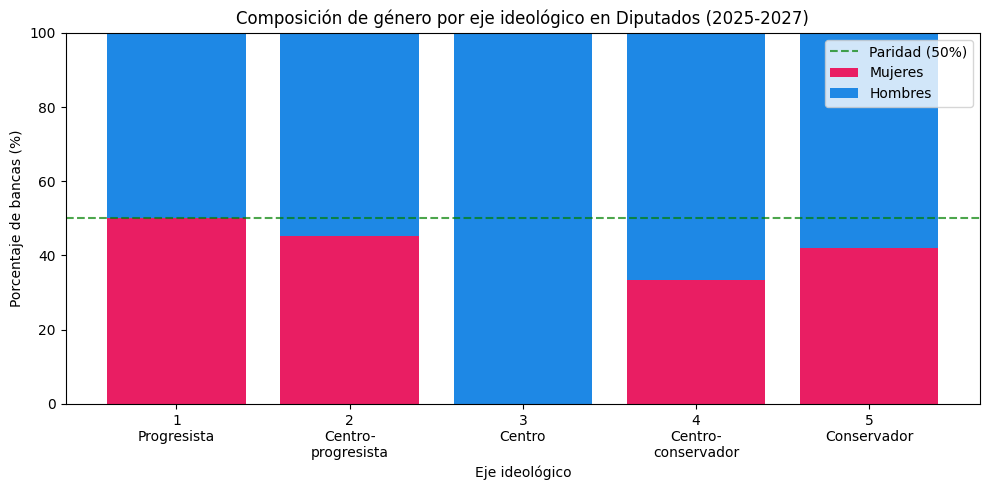

In [69]:
# Filtrar solo ejes clasificados (1, 2, 3, 4, 5)
resultado_clasificados = resultado[resultado['eje'].isin([1, 2, 3, 4, 5])].copy()

# Calcular porcentajes por eje
totales_por_eje = resultado_clasificados.groupby('eje')['bancas'].transform('sum')
resultado_clasificados['porcentaje'] = (resultado_clasificados['bancas'] / totales_por_eje) * 100

# Pivotear
pivot = resultado_clasificados.pivot(index='eje', columns='genero', values='porcentaje').fillna(0)
pivot = pivot.reindex([1, 2, 3, 4, 5])  # Ordenar ejes

# Graficar
fig, ax = plt.subplots(figsize=(10, 5))

# Barras apiladas
ax.bar(pivot.index, pivot['femenino'], label='Mujeres', color='#E91E63')
ax.bar(pivot.index, pivot['masculino'], bottom=pivot['femenino'], label='Hombres', color='#1E88E5')

# Línea de paridad
ax.axhline(50, color='green', linestyle='--', alpha=0.7, label='Paridad (50%)')

# Etiquetas
ax.set_xlabel('Eje ideológico')
ax.set_ylabel('Porcentaje de bancas (%)')
ax.set_title('Composición de género por eje ideológico en Diputados (2025-2027)')
ax.legend()
ax.set_ylim(0, 100)
ax.set_xticks([1, 2, 3, 4, 5])
ax.set_xticklabels(['1\nProgresista', '2\nCentro-\nprogresista', '3\nCentro', '4\nCentro-\nconservador', '5\nConservador'])

plt.tight_layout()
plt.show()

In [70]:
# Calcular porcentajes por eje ideológico
print("="*60)
print("COMPOSICIÓN DE GÉNERO POR EJE IDEOLÓGICO - DIPUTADOS (2025-2027)")
print("="*60)

# Filtrar solo ejes clasificados
resultado_clasificados = resultado[resultado['eje'].isin([1, 2, 3, 4, 5])].copy()

# Calcular totales por eje
for eje in [1, 2, 3, 4, 5]:
    datos_eje = resultado_clasificados[resultado_clasificados['eje'] == eje]
    total_eje = datos_eje['bancas'].sum()
    
    if total_eje > 0:
        mujeres = datos_eje[datos_eje['genero'] == 'femenino']['bancas'].sum()
        hombres = datos_eje[datos_eje['genero'] == 'masculino']['bancas'].sum()
        
        pct_mujeres = round((mujeres / total_eje) * 100, 1)
        pct_hombres = round((hombres / total_eje) * 100, 1)
        
        # Nombre del eje
        if eje == 1: nombre = "Progresista"
        elif eje == 2: nombre = "Centro-progresista"
        elif eje == 3: nombre = "Centro"
        elif eje == 4: nombre = "Centro-conservador"
        elif eje == 5: nombre = "Conservador"
        
        print(f"\n📐 Eje {eje} ({nombre}): Total {total_eje} bancas")
        print(f"   Mujeres: {mujeres} ({pct_mujeres}%)")
        print(f"   Hombres: {hombres} ({pct_hombres}%)")
    else:
        print(f"\n📐 Eje {eje}: Sin datos")

# No clasificados
no_clasificados = resultado[resultado['eje'] == 'no_confirmado']
if not no_clasificados.empty:
    total_no_clasif = no_clasificados['bancas'].sum()
    print(f"\n⚠️ Sin clasificación ideológica: {total_no_clasif} bancas")
    print(no_clasificados.to_string(index=False))

COMPOSICIÓN DE GÉNERO POR EJE IDEOLÓGICO - DIPUTADOS (2025-2027)

📐 Eje 1 (Progresista): Total 4 bancas
   Mujeres: 2 (50.0%)
   Hombres: 2 (50.0%)

📐 Eje 2 (Centro-progresista): Total 93 bancas
   Mujeres: 42 (45.2%)
   Hombres: 51 (54.8%)

📐 Eje 3 (Centro): Total 2 bancas
   Mujeres: 0 (0.0%)
   Hombres: 2 (100.0%)

📐 Eje 4 (Centro-conservador): Total 12 bancas
   Mujeres: 4 (33.3%)
   Hombres: 8 (66.7%)

📐 Eje 5 (Conservador): Total 95 bancas
   Mujeres: 40 (42.1%)
   Hombres: 55 (57.9%)

⚠️ Sin clasificación ideológica: 51 bancas
   genero           eje  bancas
 femenino no_confirmado      18
masculino no_confirmado      33


#### COMPOSICIÓN DE GÉNERO POR EJE IDEOLÓGICO - SENADORES (2025-2027)

In [71]:
# Filtrar senadores de CN_25_27
senadores_actuales = CN_25_27[CN_25_27['camara'] == 'senado'].copy()

# Unir con barómetro para eje ideológico
senadores_actuales = senadores_actuales.merge(barometro, left_on='bloque', right_on='bloque', how='left')
senadores_actuales['eje'] = senadores_actuales['eje'].fillna('no_confirmado')

# Resultados por género y eje
resultado_sen = senadores_actuales.groupby(['genero', 'eje']).size().reset_index(name='bancas')
resultado_sen = resultado_sen.sort_values(['eje', 'genero'])

In [72]:
# Filtrar solo ejes clasificados
resultado_sen_clasificados = resultado_sen[resultado_sen['eje'].isin([1, 2, 3, 4, 5])].copy()

# Calcular totales por eje
for eje in [1, 2, 3, 4, 5]:
    datos_eje = resultado_sen_clasificados[resultado_sen_clasificados['eje'] == eje]
    total_eje = datos_eje['bancas'].sum()
    
    if total_eje > 0:
        mujeres = datos_eje[datos_eje['genero'] == 'femenino']['bancas'].sum()
        hombres = datos_eje[datos_eje['genero'] == 'masculino']['bancas'].sum()
        
        pct_mujeres = round((mujeres / total_eje) * 100, 1)
        pct_hombres = round((hombres / total_eje) * 100, 1)
        
        # Nombre del eje
        if eje == 1: nombre = "Progresista"
        elif eje == 2: nombre = "Centro-progresista"
        elif eje == 3: nombre = "Centro"
        elif eje == 4: nombre = "Centro-conservador"
        elif eje == 5: nombre = "Conservador"
        
        print(f"\n📐 Eje {eje} ({nombre}): Total {total_eje} bancas")
        print(f"   Mujeres: {mujeres} ({pct_mujeres}%)")
        print(f"   Hombres: {hombres} ({pct_hombres}%)")
    else:
        print(f"\n📐 Eje {eje}: Sin datos")

# No clasificados
no_clasificados_sen = resultado_sen[resultado_sen['eje'] == 'no_confirmado']
if not no_clasificados_sen.empty:
    total_no_clasif = no_clasificados_sen['bancas'].sum()
    print(f"\n⚠️ Sin clasificación ideológica: {total_no_clasif} bancas")
    print(no_clasificados_sen.to_string(index=False))

# Totales generales
print("\n" + "="*60)
print("RESUMEN SENADORES")
print("="*60)
print(f"Total senadores: {len(senadores_actuales)}")
print(f"Mujeres: {len(senadores_actuales[senadores_actuales['genero'] == 'femenino'])}")
print(f"Hombres: {len(senadores_actuales[senadores_actuales['genero'] == 'masculino'])}")


📐 Eje 1: Sin datos

📐 Eje 2 (Centro-progresista): Total 21 bancas
   Mujeres: 9 (42.9%)
   Hombres: 12 (57.1%)

📐 Eje 3: Sin datos

📐 Eje 4 (Centro-conservador): Total 3 bancas
   Mujeres: 2 (66.7%)
   Hombres: 1 (33.3%)

📐 Eje 5 (Conservador): Total 20 bancas
   Mujeres: 8 (40.0%)
   Hombres: 12 (60.0%)

⚠️ Sin clasificación ideológica: 28 bancas
   genero           eje  bancas
 femenino no_confirmado      14
masculino no_confirmado      14

RESUMEN SENADORES
Total senadores: 72
Mujeres: 33
Hombres: 39


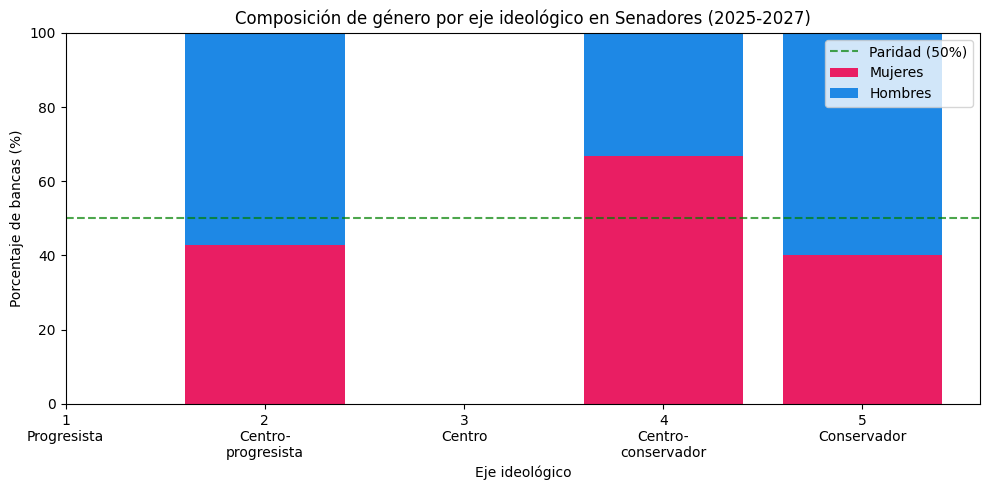

In [73]:
# 1. Calcular porcentajes por eje
resultado_sen_porc = resultado_sen_clasificados.copy()
totales_por_eje_sen = resultado_sen_porc.groupby('eje')['bancas'].transform('sum')
resultado_sen_porc['porcentaje'] = (resultado_sen_porc['bancas'] / totales_por_eje_sen) * 100

# 2. Pivotear
pivot_sen = resultado_sen_porc.pivot(index='eje', columns='genero', values='porcentaje').fillna(0)
pivot_sen = pivot_sen.reindex([1, 2, 3, 4, 5])

# 3. Graficar
fig, ax = plt.subplots(figsize=(10, 5))

# Barras apiladas
ax.bar(pivot_sen.index, pivot_sen['femenino'], label='Mujeres', color='#E91E63')
ax.bar(pivot_sen.index, pivot_sen['masculino'], bottom=pivot_sen['femenino'], label='Hombres', color='#1E88E5')

# Línea de paridad
ax.axhline(50, color='green', linestyle='--', alpha=0.7, label='Paridad (50%)')

# Etiquetas
ax.set_xlabel('Eje ideológico')
ax.set_ylabel('Porcentaje de bancas (%)')
ax.set_title('Composición de género por eje ideológico en Senadores (2025-2027)')
ax.legend()
ax.set_ylim(0, 100)
ax.set_xticks([1, 2, 3, 4, 5])
ax.set_xticklabels(['1\nProgresista', '2\nCentro-\nprogresista', '3\nCentro', '4\nCentro-\nconservador', '5\nConservador'])

plt.tight_layout()
plt.show()

#### COMPARACIÓN GÉNERO ENTRE CÁMARAS

COMPARACIÓN DE GÉNERO ENTRE CÁMARAS
Diputados: 257 bancas
   Mujeres: 106 (41.2%)
   Hombres: 151 (58.8%)

Senadores: 72 bancas
   Mujeres: 33 (45.8%)
   Hombres: 39 (54.2%)


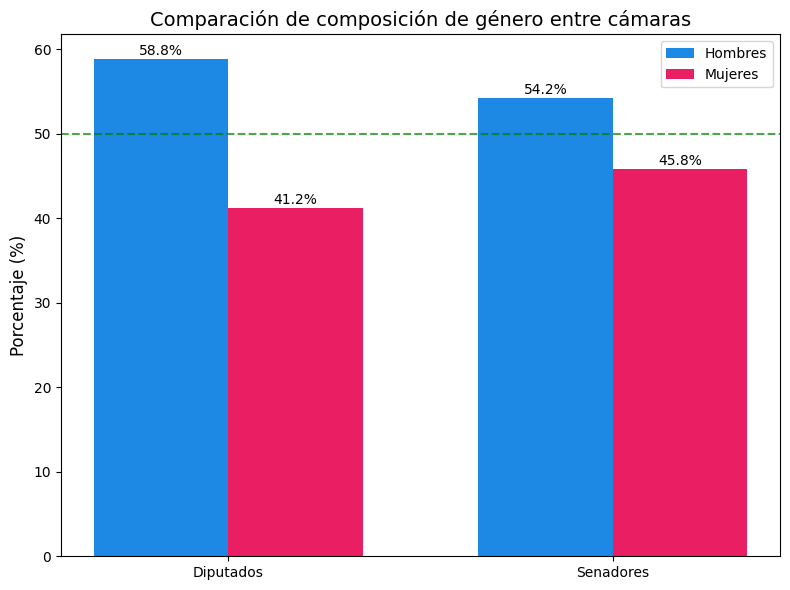

In [74]:
# Calcular porcentajes con tus datos actuales
total_diputados = len(diputados_actuales)
total_senadores = len(senadores_actuales)

mujeres_dip = len(diputados_actuales[diputados_actuales['genero'] == 'femenino'])
hombres_dip = len(diputados_actuales[diputados_actuales['genero'] == 'masculino'])

mujeres_sen = len(senadores_actuales[senadores_actuales['genero'] == 'femenino'])
hombres_sen = len(senadores_actuales[senadores_actuales['genero'] == 'masculino'])

hombres_pct = [round((hombres_dip / total_diputados) * 100, 1), 
               round((hombres_sen / total_senadores) * 100, 1)]
mujeres_pct = [round((mujeres_dip / total_diputados) * 100, 1), 
               round((mujeres_sen / total_senadores) * 100, 1)]

print("="*60)
print("COMPARACIÓN DE GÉNERO ENTRE CÁMARAS")
print("="*60)
print(f"Diputados: {total_diputados} bancas")
print(f"   Mujeres: {mujeres_dip} ({mujeres_pct[0]}%)")
print(f"   Hombres: {hombres_dip} ({hombres_pct[0]}%)")
print(f"\nSenadores: {total_senadores} bancas")
print(f"   Mujeres: {mujeres_sen} ({mujeres_pct[1]}%)")
print(f"   Hombres: {hombres_sen} ({hombres_pct[1]}%)")

# Gráfico
camaras = ['Diputados', 'Senadores']
x = np.arange(len(camaras))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 6))
bars1 = ax.bar(x - width/2, hombres_pct, width, label='Hombres', color='#1E88E5')
bars2 = ax.bar(x + width/2, mujeres_pct, width, label='Mujeres', color='#E91E63')

ax.set_ylabel('Porcentaje (%)', fontsize=12)
ax.set_title('Comparación de composición de género entre cámaras', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(camaras)
ax.legend()
ax.axhline(50, color='green', linestyle='--', alpha=0.7, label='Paridad (50%)')

for bar in bars1 + bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, 
            f'{bar.get_height():.1f}%', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

#### ENCABEZAMIENTOS

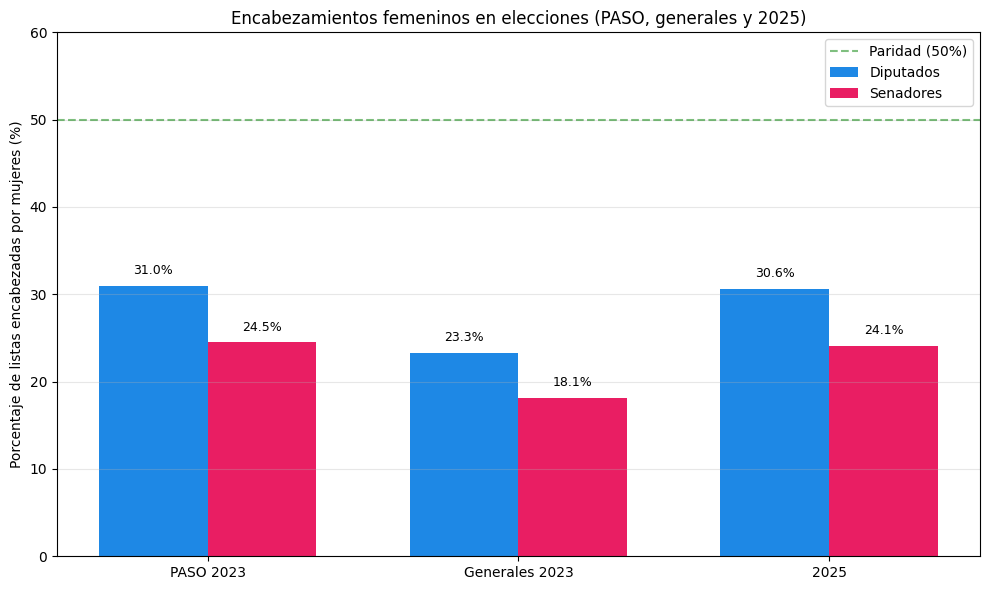


RESUMEN ENCABEZAMIENTOS FEMENINOS
      Elección    Cámara  Porcentaje
     PASO 2023 Diputados   31.000000
     PASO 2023 Senadores   24.500000
Generales 2023 Diputados   23.333333
Generales 2023 Senadores   18.125000
          2025 Diputados   30.625000
          2025 Senadores   24.125000

NOTA: Los valores son promedios entre todas las jurisdicciones


In [75]:
# ENCABEZAMIENTOS FEMENINOS EN ELECCIONES 2023 y 2025
# Porcentaje de listas encabezadas por mujeres (sin filtrar por competitividad)

# 1. Preparar datos para 2023
# PASO 2023
promedio_paso_hcdn = E_23_PASO[E_23_PASO['camara'] == 'HCDN']['% listas encabezadas por mujeres'].mean()
promedio_paso_hsn = E_23_PASO[E_23_PASO['camara'] == 'HSN']['% listas encabezadas por mujeres'].mean()

# Generales 2023
promedio_generales_hcdn = E_23_generales[E_23_generales['camara'] == 'HCDN']['% listas encabezadas por mujeres'].mean()
promedio_generales_hsn = E_23_generales[E_23_generales['camara'] == 'HSN']['% listas encabezadas por mujeres'].mean()

# 2. Preparar datos para 2025 (no tienen columna 'camara', son específicos por df)
promedio_2025_hcdn = E_25_HCDN['% listas encabezadas por mujeres'].mean()
promedio_2025_hsn = E_25_HSN['% listas encabezadas por mujeres'].mean()

# 3. Crear DataFrame para graficar
datos = {
    'Elección': ['PASO 2023', 'PASO 2023', 'Generales 2023', 'Generales 2023', '2025', '2025'],
    'Cámara': ['Diputados', 'Senadores', 'Diputados', 'Senadores', 'Diputados', 'Senadores'],
    'Porcentaje': [promedio_paso_hcdn, promedio_paso_hsn, promedio_generales_hcdn, promedio_generales_hsn, promedio_2025_hcdn, promedio_2025_hsn]
}

df_viz = pd.DataFrame(datos)

# 4. Graficar
fig, ax = plt.subplots(figsize=(10, 6))

# Colores por cámara
colores = {'Diputados': '#1E88E5', 'Senadores': '#E91E63'}

# Posiciones
x = np.arange(len(df_viz['Elección'].unique()))
width = 0.35
offsets = {'Diputados': -width/2, 'Senadores': width/2}

for camara in ['Diputados', 'Senadores']:
    subset = df_viz[df_viz['Cámara'] == camara]
    x_pos = np.arange(len(subset)) + offsets[camara]
    ax.bar(x_pos, subset['Porcentaje'], width, label=camara, color=colores[camara])
    
    # Añadir etiquetas
    for i, (_, row) in enumerate(subset.iterrows()):
        ax.text(x_pos[i], row['Porcentaje'] + 1, f"{row['Porcentaje']:.1f}%", 
                ha='center', va='bottom', fontsize=9)

# Configuración
ax.set_ylabel('Porcentaje de listas encabezadas por mujeres (%)')
ax.set_title('Encabezamientos femeninos en elecciones (PASO, generales y 2025)')
ax.set_xticks(np.arange(len(df_viz['Elección'].unique())))
ax.set_xticklabels(['PASO 2023', 'Generales 2023', '2025'])
ax.set_ylim(0, 60)
ax.axhline(50, color='green', linestyle='--', alpha=0.5, label='Paridad (50%)')
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# 5. Tabla resumen
print("\n" + "="*60)
print("RESUMEN ENCABEZAMIENTOS FEMENINOS")
print("="*60)
print(df_viz.to_string(index=False))
print("\n" + "="*60)
print("NOTA: Los valores son promedios entre todas las jurisdicciones")

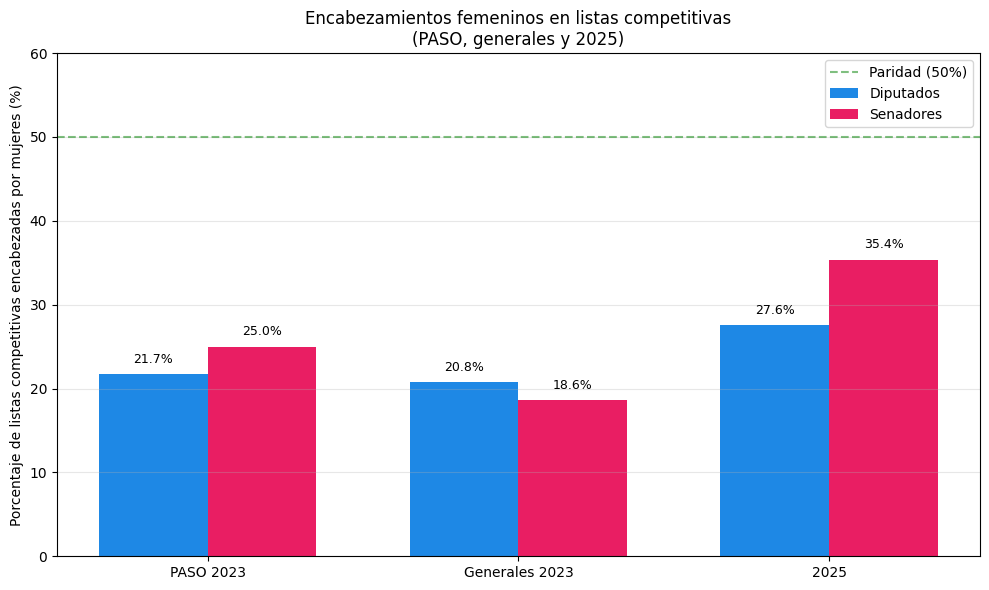


RESUMEN ENCABEZAMIENTOS FEMENINOS EN LISTAS COMPETITIVAS
      Elección    Cámara  Porcentaje
     PASO 2023 Diputados   21.708333
     PASO 2023 Senadores   25.000000
Generales 2023 Diputados   20.750000
Generales 2023 Senadores   18.625000
          2025 Diputados   27.583333
          2025 Senadores   35.375000

NOTA: Los valores son promedios entre todas las jurisdicciones
      'Listas competitivas' = listas que superaron el piso electoral


In [76]:
# VISUALIZACIÓN: ENCABEZAMIENTOS FEMENINOS EN LISTAS COMPETITIVAS

# 1. Preparar datos para 2023
# PASO 2023 - listas competitivas
promedio_paso_hcdn_comp = E_23_PASO[E_23_PASO['camara'] == 'HCDN']['% listas competitivas encabezadas por mujeres'].mean()
promedio_paso_hsn_comp = E_23_PASO[E_23_PASO['camara'] == 'HSN']['% listas competitivas encabezadas por mujeres'].mean()

# Generales 2023 - listas competitivas
promedio_generales_hcdn_comp = E_23_generales[E_23_generales['camara'] == 'HCDN']['% listas competitivas encabezadas por mujeres'].mean()
promedio_generales_hsn_comp = E_23_generales[E_23_generales['camara'] == 'HSN']['% listas competitivas encabezadas por mujeres'].mean()

# 2. Preparar datos para 2025 (asumiendo que tienen la misma columna)
promedio_2025_hcdn_comp = E_25_HCDN['% listas competitivas encabezadas por mujeres'].mean()
promedio_2025_hsn_comp = E_25_HSN['% listas competitivas encabezadas por mujeres'].mean()

# 3. Crear DataFrame para graficar
datos_competitivas = {
    'Elección': ['PASO 2023', 'PASO 2023', 'Generales 2023', 'Generales 2023', '2025', '2025'],
    'Cámara': ['Diputados', 'Senadores', 'Diputados', 'Senadores', 'Diputados', 'Senadores'],
    'Porcentaje': [
        promedio_paso_hcdn_comp, promedio_paso_hsn_comp,
        promedio_generales_hcdn_comp, promedio_generales_hsn_comp,
        promedio_2025_hcdn_comp, promedio_2025_hsn_comp
    ]
}

df_viz_competitivas = pd.DataFrame(datos_competitivas)

# 4. Graficar
fig, ax = plt.subplots(figsize=(10, 6))

# Colores por cámara
colores = {'Diputados': '#1E88E5', 'Senadores': '#E91E63'}

# Posiciones
x = np.arange(len(df_viz_competitivas['Elección'].unique()))
width = 0.35
offsets = {'Diputados': -width/2, 'Senadores': width/2}

for camara in ['Diputados', 'Senadores']:
    subset = df_viz_competitivas[df_viz_competitivas['Cámara'] == camara]
    x_pos = np.arange(len(subset)) + offsets[camara]
    ax.bar(x_pos, subset['Porcentaje'], width, label=camara, color=colores[camara])
    
    # Añadir etiquetas
    for i, (_, row) in enumerate(subset.iterrows()):
        ax.text(x_pos[i], row['Porcentaje'] + 1, f"{row['Porcentaje']:.1f}%", 
                ha='center', va='bottom', fontsize=9)

# Configuración
ax.set_ylabel('Porcentaje de listas competitivas encabezadas por mujeres (%)')
ax.set_title('Encabezamientos femeninos en listas competitivas\n(PASO, generales y 2025)')
ax.set_xticks(np.arange(len(df_viz_competitivas['Elección'].unique())))
ax.set_xticklabels(['PASO 2023', 'Generales 2023', '2025'])
ax.set_ylim(0, 60)
ax.axhline(50, color='green', linestyle='--', alpha=0.5, label='Paridad (50%)')
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# 5. Tabla resumen
print("\n" + "="*60)
print("RESUMEN ENCABEZAMIENTOS FEMENINOS EN LISTAS COMPETITIVAS")
print("="*60)
print(df_viz_competitivas.to_string(index=False))
print("\n" + "="*60)
print("NOTA: Los valores son promedios entre todas las jurisdicciones")
print("      'Listas competitivas' = listas que superaron el piso electoral")

In [88]:
# ============================================================================
# PREPARAR DATOS: Unificar los tres momentos electorales
# ============================================================================

# Lista de columnas LCEM (ejes ideológicos)
columnas_eje = ['LCEM_Eje_1_Progresista', 'LCEM_Eje_2_Centro_Progresista', 'LCEM_Eje_3_Centro',
                'LCEM_Eje_4_Centro_Conservador', 'LCEM_Eje_5_Conservador']

# Nombres legibles para los ejes
nombres_ejes = {
    'LCEM_Eje_1_Progresista': 'Eje 1: Progresista',
    'LCEM_Eje_2_Centro_Progresista': 'Eje 2: Centroizquierda',
    'LCEM_Eje_3_Centro': 'Eje 3: Centro',
    'LCEM_Eje_4_Centro_Conservador': 'Eje 4: Centroderecha',
    'LCEM_Eje_5_Conservador': 'Eje 5: Conservador',
}

# Orden correcto de elecciones
orden_elecciones = ['PASO 2023', 'Generales 2023', '2025']

# 1. Procesar PASO 2023 (Diputados)
paso_dip = E_23_PASO[E_23_PASO['camara'] == 'HCDN'].copy()
paso_dip['eleccion'] = 'PASO 2023'
paso_dip['camara_nombre'] = 'Diputados'

# 2. Procesar PASO 2023 (Senadores)
paso_sen = E_23_PASO[E_23_PASO['camara'] == 'HSN'].copy()
paso_sen['eleccion'] = 'PASO 2023'
paso_sen['camara_nombre'] = 'Senadores'

# 3. Procesar Generales 2023 (Diputados)
gen_dip = E_23_generales[E_23_generales['camara'] == 'HCDN'].copy()
gen_dip['eleccion'] = 'Generales 2023'
gen_dip['camara_nombre'] = 'Diputados'

# 4. Procesar Generales 2023 (Senadores)
gen_sen = E_23_generales[E_23_generales['camara'] == 'HSN'].copy()
gen_sen['eleccion'] = 'Generales 2023'
gen_sen['camara_nombre'] = 'Senadores'

# 5. Procesar 2025 (Diputados)
e25_dip = E_25_HCDN.copy()
e25_dip['eleccion'] = '2025'
e25_dip['camara_nombre'] = 'Diputados'  # ← CORREGIDO

# 6. Procesar 2025 (Senadores)
e25_sen = E_25_HSN.copy()
e25_sen['eleccion'] = '2025'
e25_sen['camara_nombre'] = 'Senadores'  # ← CORREGIDO

# Unir todos los DataFrames
dfs_elecciones = [paso_dip, paso_sen, gen_dip, gen_sen, e25_dip, e25_sen]
df_total = pd.concat(dfs_elecciones, ignore_index=True)

# Añadir columna Centro si no existe
if 'LCEM_Eje_3_Centro' not in df_total.columns:
    df_total['LCEM_Eje_3_Centro'] = 0
    print("✅ Columna LCEM_Eje_3_Centro añadida con valores 0")

# Verificar que todo está bien
print(f"\n📊 DataFrame total creado:")
print(f"   Filas: {len(df_total)}")
print(f"   Columnas: {df_total.columns.tolist()}")
print(f"   Cámaras: {df_total['camara_nombre'].unique()}")
print(f"   Elecciones: {df_total['eleccion'].unique()}")

✅ Columna LCEM_Eje_3_Centro añadida con valores 0

📊 DataFrame total creado:
   Filas: 96
   Columnas: ['jurisdiccion', 'listas', 'listas encabezadas por mujeres', '% listas encabezadas por mujeres', 'listas competitivas', 'listas competitivas encabezadas por mujeres', '% listas competitivas encabezadas por mujeres', 'LCEM_Eje_1_Progresista', 'LCEM_Eje_2_Centro_Progresista', 'LCEM_Eje_4_Centro_Conservador', 'LCEM_Eje_5_Conservador', 'LCEM_Provincial', 'camara', 'eleccion', 'camara_nombre', 'LCEM_Eje_3_Centro']
   Cámaras: <StringArray>
['Diputados', 'Senadores']
Length: 2, dtype: str
   Elecciones: <StringArray>
['PASO 2023', 'Generales 2023', '2025']
Length: 3, dtype: str


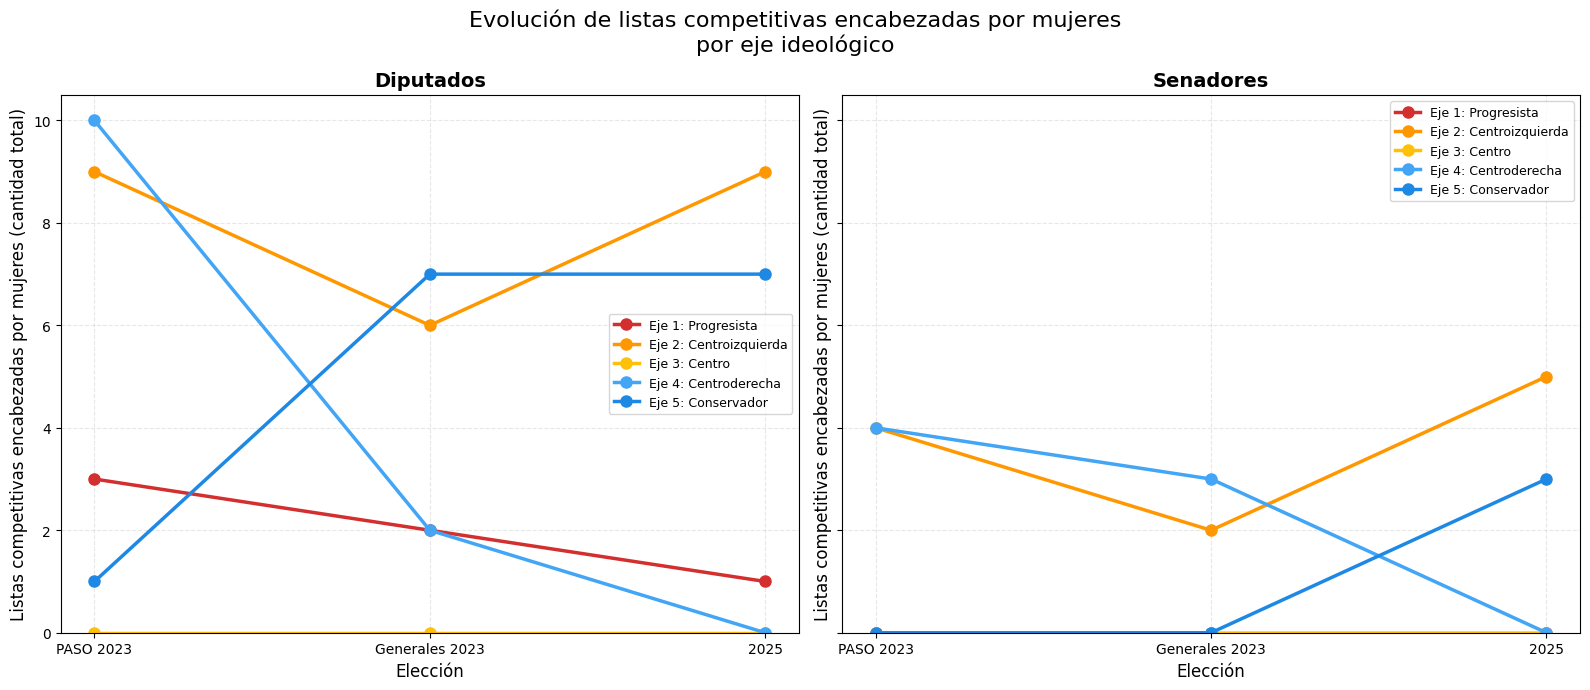

In [91]:
# ============================================================================
# GRÁFICO 1: Líneas por cámara (Diputados vs Senadores)
# ============================================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharey=True)

colores_eje = {
    'LCEM_Eje_1_Progresista': '#D32F2F',
    'LCEM_Eje_2_Centro_Progresista': '#FF9800',
    'LCEM_Eje_3_Centro': '#FFC107',
    'LCEM_Eje_4_Centro_Conservador': '#42A5F5',
    'LCEM_Eje_5_Conservador': '#1E88E5'
}

for idx, camara in enumerate(['Diputados', 'Senadores']):
    ax = axes[idx]
    df_camara = df_total[df_total['camara_nombre'] == camara]
    
    for col in columnas_eje:
        datos_eje = df_camara.groupby('eleccion')[col].sum().reindex(orden_elecciones).fillna(0)
        
        ax.plot(datos_eje.index, datos_eje.values, 
               marker='o', linewidth=2.5, markersize=8,
               label=nombres_ejes[col], color=colores_eje[col])
    
    ax.set_title(f'{camara}', fontsize=14, fontweight='bold')
    ax.set_xlabel('Elección', fontsize=12)
    ax.set_ylabel('Listas competitivas encabezadas por mujeres (cantidad total)', fontsize=12)
    ax.legend(loc='best', fontsize=9)
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.set_ylim(bottom=0)

plt.suptitle('Evolución de listas competitivas encabezadas por mujeres\npor eje ideológico', fontsize=16)
plt.tight_layout()
plt.show()

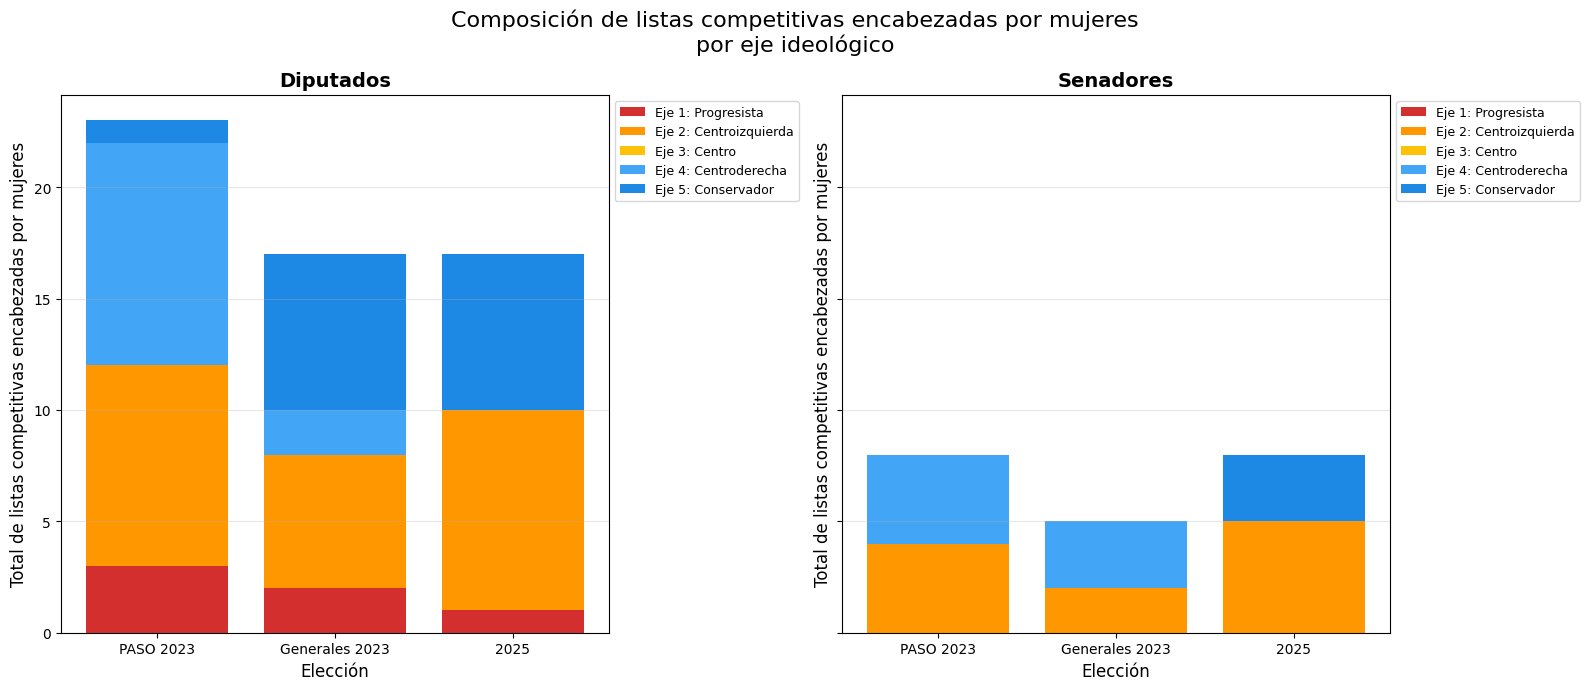

In [92]:
# ============================================================================
# GRÁFICO 2: Barras apiladas (composición total por elección)
# ============================================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharey=True)

for idx, camara in enumerate(['Diputados', 'Senadores']):
    ax = axes[idx]
    df_camara = df_total[df_total['camara_nombre'] == camara]
    
    # Agrupar y reindexar
    datos_composicion = df_camara.groupby('eleccion')[columnas_eje].sum()
    datos_composicion = datos_composicion.reindex(orden_elecciones).fillna(0)
    
    bottom = None
    for col in columnas_eje:  # Ya ordenados de izquierda a derecha
        ax.bar(datos_composicion.index, datos_composicion[col], 
               bottom=bottom, label=nombres_ejes[col], 
               color=colores_eje[col])
        if bottom is None:
            bottom = datos_composicion[col].copy()
        else:
            bottom = bottom + datos_composicion[col]
    
    ax.set_title(f'{camara}', fontsize=14, fontweight='bold')
    ax.set_xlabel('Elección', fontsize=12)
    ax.set_ylabel('Total de listas competitivas encabezadas por mujeres', fontsize=12)
    ax.legend(loc='upper left', bbox_to_anchor=(1, 1), fontsize=9)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Composición de listas competitivas encabezadas por mujeres\npor eje ideológico', fontsize=16)
plt.tight_layout()
plt.show()

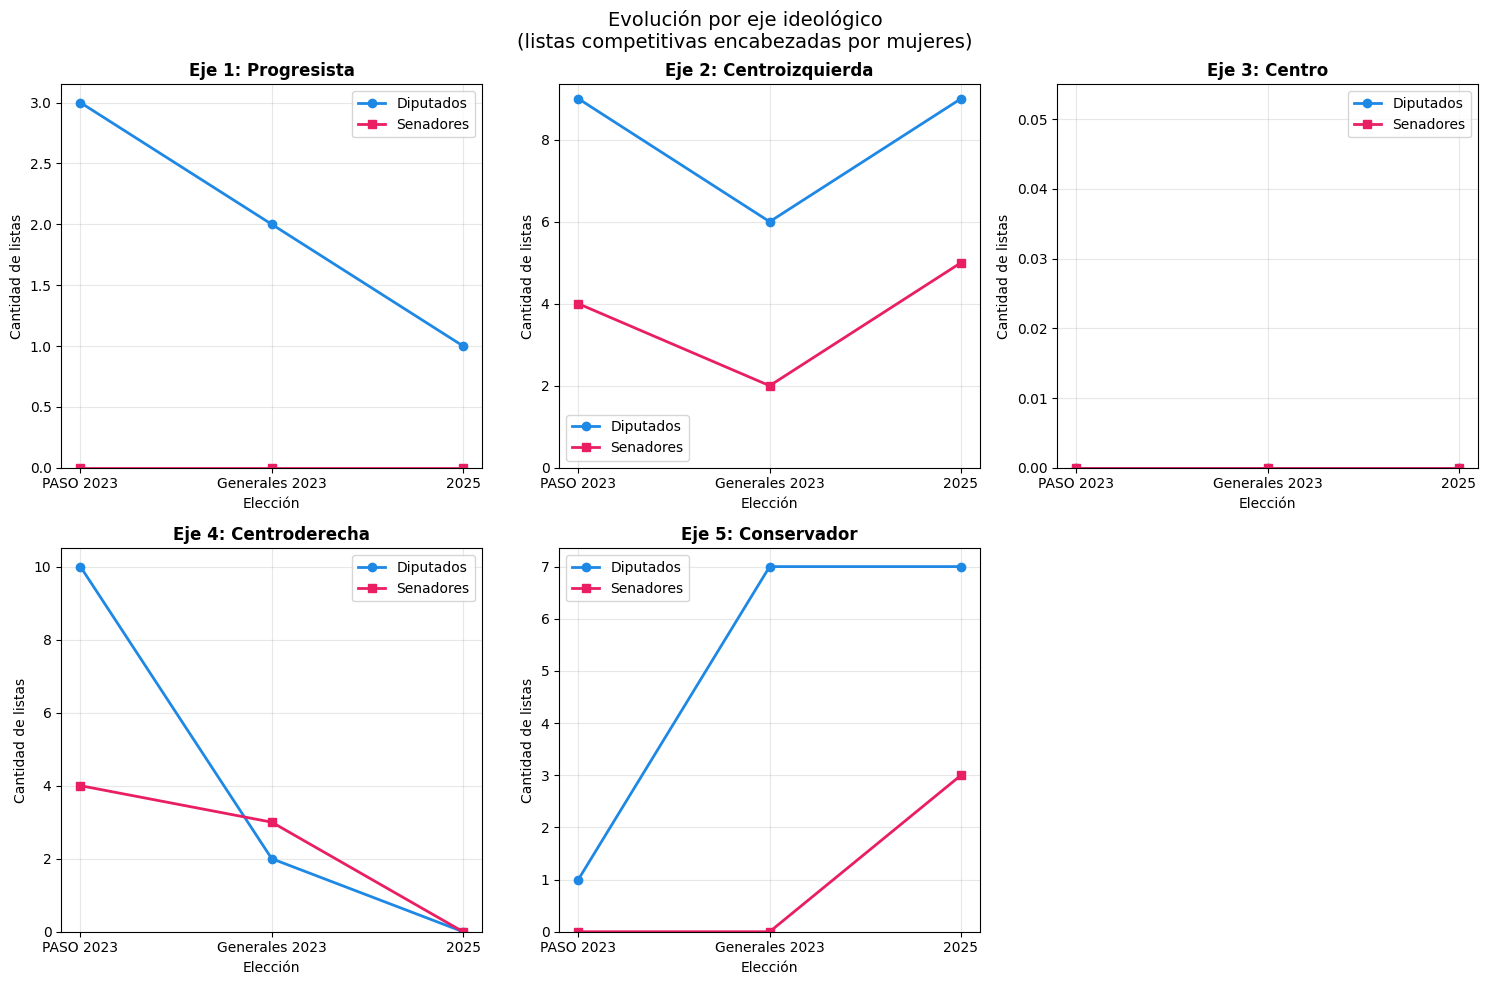

In [93]:
# ============================================================================
# GRÁFICO 3: Facetas por eje ideológico (un subplot por cada eje)
# ============================================================================

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(columnas_eje):
    ax = axes[i]
    
    # Datos para Diputados
    df_dip = df_total[df_total['camara_nombre'] == 'Diputados']
    datos_dip = df_dip.groupby('eleccion')[col].sum().reindex(orden_elecciones).fillna(0)
    
    # Datos para Senadores
    df_sen = df_total[df_total['camara_nombre'] == 'Senadores']
    datos_sen = df_sen.groupby('eleccion')[col].sum().reindex(orden_elecciones).fillna(0)
    
    ax.plot(datos_dip.index, datos_dip.values, 
           marker='o', linewidth=2, markersize=6,
           label='Diputados', color='#1E88E5')
    
    ax.plot(datos_sen.index, datos_sen.values, 
           marker='s', linewidth=2, markersize=6,
           label='Senadores', color='#E91E63')
    
    ax.set_title(nombres_ejes[col], fontsize=12, fontweight='bold')
    ax.set_xlabel('Elección', fontsize=10)
    ax.set_ylabel('Cantidad de listas', fontsize=10)
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_ylim(bottom=0)

# Ocultar el sexto subplot si está vacío (2x3 = 6, tenemos 5 ejes)
axes[5].set_visible(False)

plt.suptitle('Evolución por eje ideológico\n(listas competitivas encabezadas por mujeres)', fontsize=14)
plt.tight_layout()
plt.show()

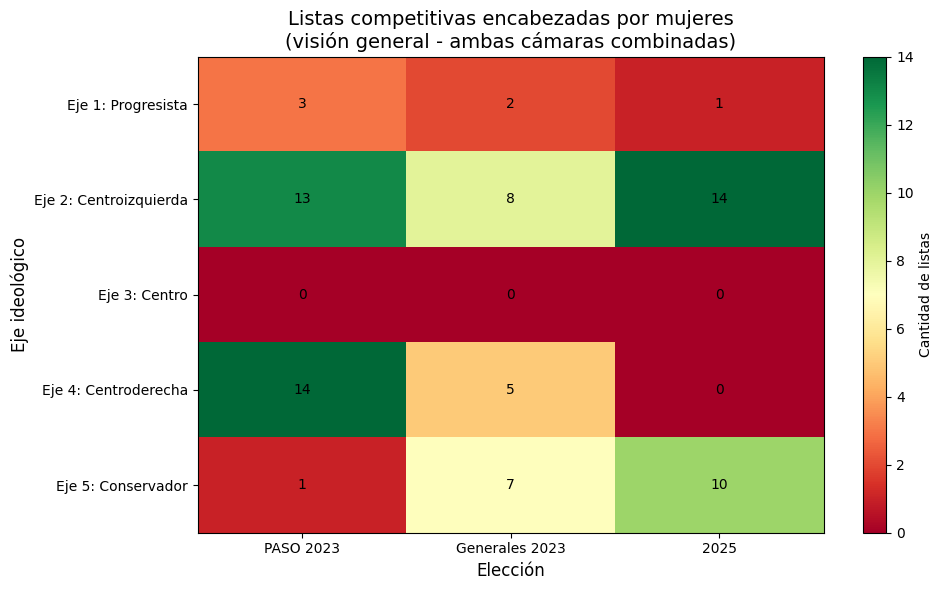

In [94]:
# ============================================================================
# GRÁFICO EXTRA: Mapa de calor
# ============================================================================

# Preparar datos (suma de ambas cámaras)
df_heatmap = df_total.groupby(['eleccion'])[columnas_eje].sum()
df_heatmap = df_heatmap.reindex(orden_elecciones).fillna(0)
df_heatmap_t = df_heatmap.T  # Transponer

fig, ax = plt.subplots(figsize=(10, 6))

im = ax.imshow(df_heatmap_t.values, cmap='RdYlGn', aspect='auto', vmin=0)

ax.set_xticks(np.arange(len(df_heatmap_t.columns)))
ax.set_yticks(np.arange(len(df_heatmap_t.index)))
ax.set_xticklabels(df_heatmap_t.columns)
ax.set_yticklabels([nombres_ejes[col] for col in df_heatmap_t.index])
ax.set_xlabel('Elección', fontsize=12)
ax.set_ylabel('Eje ideológico', fontsize=12)
ax.set_title('Listas competitivas encabezadas por mujeres\n(visión general - ambas cámaras combinadas)', fontsize=14)

# Añadir valores en cada celda
for i in range(len(df_heatmap_t.index)):
    for j in range(len(df_heatmap_t.columns)):
        text = ax.text(j, i, f"{int(df_heatmap_t.iloc[i, j])}",
                       ha="center", va="center", color="black", fontsize=10)

plt.colorbar(im, ax=ax, label='Cantidad de listas')
plt.tight_layout()
plt.show()

### **Notas**

## Asignación de bancas en Argentina

### Diputados (Cámara Baja)
- **Sistema**: Proporcional por lista (D'Hondt)
- **Renovación**: Por mitades cada 2 años
- **Bancas totales**: 257
- **Bancas por distrito**: Variable (Buenos Aires 70, CABA 25, provincias chicas 5)
- **Ley de paridad (2017)**: Las listas deben alternar entre mujeres y varones (mujer-varón-mujer o varón-mujer-varón)

**Distribución de bancas por tipo de lista:**
| Tipo de lista | Bancas | Género | Observación |
| :--- | :--- | :--- | :--- |
| **Lista ganadora (mayoría)** | ~50-70% de las bancas del distrito | Alternancia obligatoria | La paridad se traduce en bancas reales |
| **Listas minoritarias** | Resto de bancas | Depende de la posición | La cabeza de lista tiene más chances |

**Proporcional por lista (D'Hondt)**
- Obtener un mínimo del 3% para ser elegido
- Cociente ente el total de votos obtenidos y las bancas en juego

### Senadores (Cámara Alta)
- **Sistema**: Mayoría automática (2 bancas para el ganador, 1 para el segundo)
- **Renovación**: Por tercios cada 2 años
- **Bancas totales**: 72 (3 por provincia)
- **Ley de paridad**: También aplica alternancia en las listas

**Distribución de bancas por tipo de lista:**
| Tipo de lista | Bancas | Género | Observación |
| :--- | :--- | :--- | :--- |
| **Lista ganadora (mayoría)** | 2 bancas | 1 mujer + 1 varón | Obligatorio por ley de paridad |
| **Lista perdedora (minoría)** | 1 banca | Depende de quién encabece | Crítico para representación femenina |

### Diferencia clave

| Cámara | Lista mayoritaria | Lista minoritaria |
| :--- | :--- | :--- |
| **Diputados** | La paridad asegura representación femenina (~50-70% bancas) | La posición define el género (~30-50% bancas) |
| **Senadores** | 2 bancas (1 mujer + 1 varón) por ley (100% de las bancas del distrito) | 1 banca (género según cabeza de lista) |

### Impacto en tus datos

La **LCEM** (Lista Competitiva Encabezada por Mujer) es clave porque:
- En **Senadores**, la lista minoritaria es UNA sola banca. Si la encabeza un varón → 0 mujeres en esa provincia
- En **Diputados**, ser cabeza de lista aumenta probabilidad de resultar electa
- Por eso tu análisis de LCEM es crucial para entender la representación real, no solo la paridad formal